<a href="https://colab.research.google.com/github/jeyner99/Integraci-n-de-datos-y-prospectiva/blob/main/Reto_1_Caracterizaci%C3%B3n_de_Variables_Aleatorias_Jeyner_Casta%C3%B1o%2C_Brainer_Arango.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Caso de estudio LATAM Airlines(creado con claude AI)

- LATAM Airlines Group es el mayor grupo aéreo de América Latina, con presencia en múltiples países de la región y una flota que, al cierre de 2025, alcanzó 371 aeronaves, proyectando llegar a 410 durante 2026, lo que la posiciona entre las 12 aerolíneas con mayor flota del mundo.

- Como práctica comercial habitual en la industria, LATAM vende más tiquetes que asientos disponibles (overbooking), asumiendo el riesgo de que se presenten más pasajeros que cupos, con el fin de compensar el efecto de los “no-shows” (pasajeros que no se presentan al vuelo) y maximizar la ocupación de sus aeronaves.

- La empresa está interesada en desarrollar un sistema por adaptación y aprendizaje que le permita proyectar, desde la gestión de sus riesgos, el porcentaje óptimo de sobreventa por vuelo y por ruta, minimizando tanto los asientos vacíos como las compensaciones por denegación de embarque.

Las variables que serán utilizadas para este proceso son las siguientes:

Vuelos semanales: Indica la cantidad de vuelos que realizó la aerolínea en esa semana.

Overbooking: Es la cantidad de veces que se materializó el riesgo de overbooking, es decir las veces que llegaron más personas de los cupos que habían para el vuelo.

Compensación: Es el dinero que gastó la aerolínea en esa semana compensando a los pasajeros que se quedaron sin vuelo.



##0. Se cargan las librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##1. Se crea la base de datos con gemini

Lo que se hizo fue pedirle que generara la base de datos en el notebook de la clase, así la IA tenía mayor claridad debido a que tenía el ejemplo de cómo tenía que ser la tabla, además se definió una semilla para la generación de los números aleatorios, así siempre son los mismos y se pueden replicar los resultados, cuando se generó la tabla se trasladó el código al notebook actual, el prompt para la generación de la tabla fue el siguiente:

"Necesito que crees una base de datos nueva con mil observaciones, muy parecida a la base de datos XDB, pero en este caso eventos se va a llamar Overbooking y no son las veces que se queda un contenedor en tierra, si no que son las veces que una aerolinea tiene más personas que cupos por overbooking, es decir, Overbooking es la cantidad de vuelos que sucede y transacciones semanales sería la cantidad de vuelos de esa semana, la severidad definela en unidades de dolares, es el dinero que tiene que pagar la aerolinea cuando se materializa el riesgo, y la idea es que no defines el LDA, pero este debe de tener asimetría positiva"

In [ ]:
# Añadimos una random seed para que los resultados sigan siendo los mismos de la tabla enviada cuando se vuelva a correr el código
np.random.seed(42)

# Number of observations
n_observations = 1000

# Generate 'Semana' column
new_semana = np.arange(1, n_observations + 1)

# Generate 'Transacción Semanales' (number of flights per week)
# Similar range to original, but for flights
new_transacciones_semanales = np.random.randint(50, 500, n_observations)

# Generate 'Frecuencia' (number of overbooking incidents)
# Keeping incidents relatively low compared to flights
new_frecuencia = np.random.randint(1, 50, n_observations)

# Generate 'Severidad' (cost per incident in USD) with positive skewness
# Using a log-normal distribution for cost tends to give positive skewness
# Mean and sigma for the underlying normal distribution adjusted for reasonable USD values
new_severidad = np.random.lognormal(mean=6.5, sigma=0.8, size=n_observations) # Values will be in USD

# Create the new DataFrame
df_aerolinea = pd.DataFrame({
    'Semana': new_semana,
    'Vuelos semanales': new_transacciones_semanales,
    'Overbooking': new_frecuencia,
    'Compensación': new_severidad
})

# Display the first 5 rows of the new DataFrame
display(df_aerolinea.head())

# Save the DataFrame to an Excel file
df_aerolinea.to_excel('df_aerolinea.xlsx', index=False)
print("DataFrame 'df_aerolinea' guardado como 'df_aerolinea.xlsx'")

,Semana,Vuelos semanales,Overbooking,Compensación
0,1,152,5,938.865466
1,2,485,29,808.067934
2,3,398,4,505.247962
3,4,320,10,2297.019246
4,5,156,17,272.252884


DataFrame 'df_aerolinea' guardado como 'df_aerolinea.xlsx'


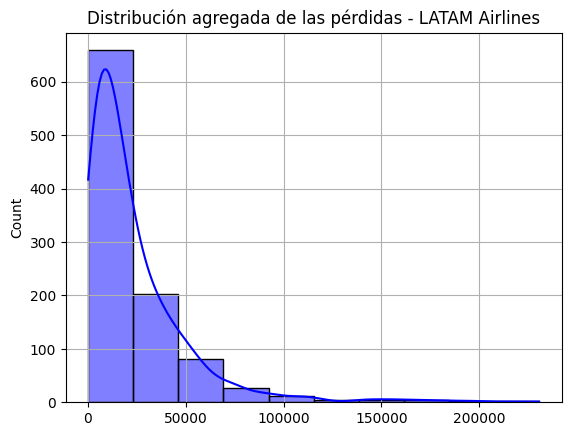

In [ ]:
Freq = df_aerolinea.iloc[:,2]
Sev = df_aerolinea.iloc[:,3]
LDA = Freq*Sev

plt.figure()
sns.histplot(LDA, color="blue", bins=10, kde = True)
plt.title("Distribución agregada de las pérdidas - LATAM Airlines")
plt.grid()
plt.show()

Interpretación de la gráfica:

La anterior gráfica nos muestra cómo se reparten los datos de la Distribución agregada de las pérdidas, podemos observar como la mayoría de los datos se inclinan hacia la izquierda, lo cual quiere decir que en la gran mayoría de los datos que se materializó el riesgo las pérdidas económicas fueron bajas, lo cual tiene sentido ya que si se ubicaran hacia la derecha el overbooking representaría grandes costos a las aerolíneas y no sería conveniente, esto pasa por ejemplo con las aseguradoras, la mayoría de los accidentes que deben de pagar son leves (rayones, luces rotas), por lo que pueden asegurar a gran cantidad de personas, y solo pocas veces se ven accidentes que requieren gran compensación(pérdida total).

In [ ]:
NI = 10 #Número de intervalos en los cuales quiero agrupar los datos
counts, Limits = np.histogram(LDA, bins = NI) #Agrupar los datos en 10 intervalos
LI = Limits[:-1] #Limites inferiores del histograma
LS = Limits[1:]  #Limites superiores del histograma
fi = counts/sum(counts) #Porcentaje de datos por intervalo
MC = (LI+LS)/2 #Marca de clase: Dato representativo de cada intervalo

df = pd.DataFrame(np.column_stack((LI, LS, counts, fi, MC)))
df.columns = ["LI", "LS", "ND", "fi", "Marca de clase"]
display(df)

,LI,LS,ND,fi,Marca de clase
0,132.205240,23183.848113,659.0,0.659,11658.026676
1,23183.848113,46235.490986,203.0,0.203,34709.669549
2,46235.490986,69287.133859,81.0,0.081,57761.312422
3,69287.133859,92338.776732,27.0,0.027,80812.955296
4,92338.776732,115390.419605,12.0,0.012,103864.598169
5,115390.419605,138442.062478,4.0,0.004,126916.241042
6,138442.062478,161493.705352,5.0,0.005,149967.883915
7,161493.705352,184545.348225,5.0,0.005,173019.526788
8,184545.348225,207596.991098,2.0,0.002,196071.169661
9,207596.991098,230648.633971,2.0,0.002,219122.812534


In [ ]:
#Media - Valor esperado de una pérdida (Qué es lo más común que pase)
u = np.sum(MC*fi)
print("La media de las pérdidas es:", u)

#Varianza - Indica que tan dispersos están los datos alrededor de la media
varc = np.sum(((MC - u)**2)*fi)
print("La varianza de las pérdidas es:", varc)

#Desviación estándar
sigma = np.sqrt(varc)
print("La desviación estándar de las pérdidas es:", sigma)

#Intervalo de variación de las pérdidas
#En este intervalo se encuentra el 95% de los datos (2*sigma)
print("El limite inferior es ", u-2*sigma)
print("El limite superior es ", u+2*sigma)

#Coeficiente de asimetría
coef_asm = np.sum((((MC-u)**3)*fi)/(sigma**3))
print("El coeficiente de asimetría es:", coef_asm)

#Coeficiente de curtosis
curtosis = np.sum((((MC-u)**4*fi))/(sigma**4))-3
coef_curt = np.sum((((MC-u)**4)*fi)/((sigma**4)))
print("El coeficiente de curtosis es:", curtosis)

La media de las pérdidas es: 25788.683757441973
La varianza de las pérdidas es: 744583661.4233649
La desviación estándar de las pérdidas es: 27287.060329455882
El limite inferior es  -28785.43690146979
El limite superior es  80362.80441635374
El coeficiente de asimetría es: 3.2060224632413385
El coeficiente de curtosis es: 13.663205136571978


**Conclusiones:**

De estas medidas de dispersión podemos realizar una serie de conclusiones.

**La varianza de las pérdidas es:** 744583661.4233649

**La desviación estándar de las pérdidas es:** 27287.060329455882
La desviación estándar refleja en dónde están ubicados la mayoría de los datos, podemos observar que estos en su mayoría están ubicados en un rango de 27287 por encima y por debajo de la media, alrededor del 65% para una desviación estándar y alrededor de 95% para 2 desviaciones estándar.

**El coeficiente de asimetría es:** 3.2060224632413385

**El coeficiente de curtosis es:** 13.663205136571978

Estos son los datos más relevantes de cómo se reparten los mil datos que tenemos, en este caso la asimetría es demasiado positiva, las asimetrías positivas reflejan que los datos están hacia la izquierda, y en efecto así es para nuestros datos, pues podemos observar en la tabla df que más del 80% de los datos están repartidos entre los primeros 2 intervalos y además observamos una cola larga hacia la derecha, la cual demuestra que son muy pocos los casos en los que se presentar una gran pérdida debido al overbooking, además la curtosis tan alta nos refleja colas muy pesadas, es decir una gran acumulación de los datos en un pequeño intervalo de los datos.

A pesar de que en general las pérdidas son bajas, estas medidas son un buen primer paso para que LATAM Airlines empiece a darle tratamiento a estas pérdidas, una opción es mejorar sus algoritmos que dictaminan cuantos cupos extras se pueden vender, así empezar a mitigar estas pérdidas, que a pesar de ser bajas representan un costo que si se mitiga se puede invertir en otras áreas del negocio, además que uno de los problemas del overbooking es un deterioro de la reputación de la empresa.